In [60]:
### plot BIONTE tree size distribution and composition

In [33]:
import pandas as pd
import numpy as np
import scipy.stats as stats
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader

In [48]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 14
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300


In [34]:
path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/BIONTE_census/'
file='BIONTE_2023v1_gapfilled_wd.csv'

In [35]:
df = pd.read_csv(path+file)

/tmp/ipykernel_1068174/3564692248.py:1: DtypeWarning: Columns (7,8,190,197,198) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+file)


In [36]:
df = df.replace(-1111.0, np.nan)    # -1111 means individual did not exist yet or too small
df = df.replace(-3333.0, np.nan)    # -3333 individual died
df = df.replace(-9999.0, np.nan)    # -9999 missing data, reason unknown

In [37]:
#df.columns.tolist()

In [38]:
ntrees=15355

In [39]:
# T0: control with no logging; 
# T1: light logging, with 33% of commercially viable biomass removed; 
# T2: medium logging, with 50% of commercially viable biomass removed; 
# T3: heavy logging, with 66% of commercially viable biomass removed. 

treatment=df['treatment'].values

In [40]:
### total ground area for each treatment ###

total_area=100.*100.*3.# m2 --  Gilberto: 3 ha per treatment

In [41]:
bionte_wd=df['WDensity'].values
print(np.nanmin(bionte_wd), np.nanmax(bionte_wd))

0.29 1.44


In [42]:
all_t0_ind=np.where(treatment =='T0')
all_t1_ind=np.where(treatment =='T1')
all_t2_ind=np.where(treatment =='T2')
all_t3_ind=np.where(treatment =='T3')

In [43]:
### read in FATES data to compare

fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
file=tag+'.elm.h0.cat.nc'
d0 = xr.open_dataset(fates_path+file)


In [44]:
nplants_unrolled=fa.scpf_to_scls_by_pft(d0.FATES_NPLANT_SZPF,d0)


In [45]:
# BIONTE
bionte_lat=-2.638
bionte_lon=360.-60.154725
lat_abs_diff = np.abs(d0.lat.data - bionte_lat)
bionte_lat_ind = np.argmin(lat_abs_diff)
lon_abs_diff = np.abs(d0.lon.data - bionte_lon)
bionte_lon_ind = np.argmin(lon_abs_diff)


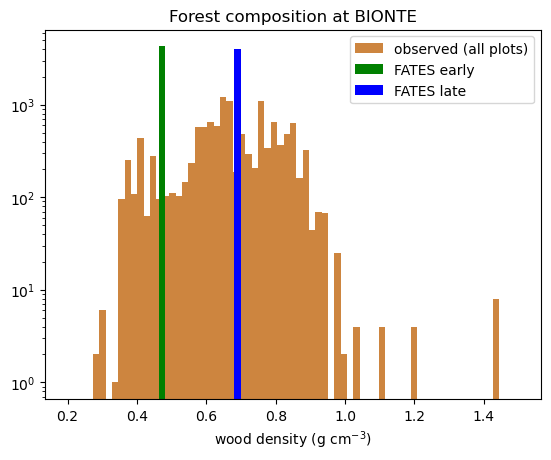

In [16]:
fates_early=nplants_unrolled.isel(fates_levscls=slice(2,13)).sum(dim='fates_levscls').mean(dim="time").isel(fates_levpft=0).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')*total_area*4
fates_late=nplants_unrolled.isel(fates_levscls=slice(2,13)).sum(dim='fates_levscls').mean(dim="time").isel(fates_levpft=1).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')*total_area*4
wd_early=0.472 #g/cm3
wd_late=0.6903

plt.hist(bionte_wd, range=(0.2,1.5), bins=71,color="peru",label="observed (all plots)")

# Add individual bars for FATES data
bar_width = (1.5-0.2)/71  # Match the histogram bin width
plt.bar(wd_early, fates_early, width=bar_width, color='green', label='FATES early')
plt.bar(wd_late, fates_late, width=bar_width, color='blue', label='FATES late')

plt.yscale('log')  # Set logarithmic y-scale
plt.xlabel('wood density (g cm$^{-3}$)')
plt.title('Forest composition at BIONTE')
plt.legend()

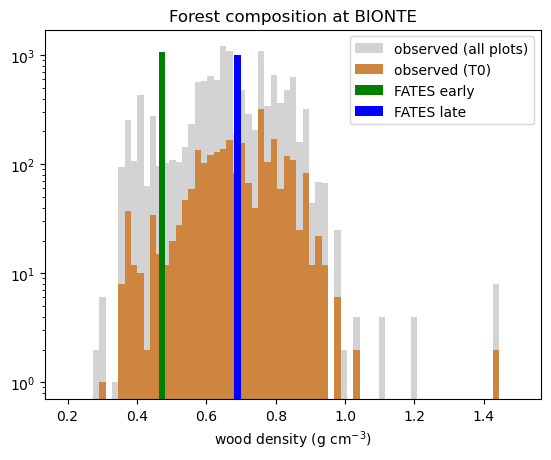

In [18]:
fates_early=nplants_unrolled.isel(fates_levscls=slice(2,13)).sum(dim='fates_levscls').mean(dim="time").isel(fates_levpft=0).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')*total_area
fates_late=nplants_unrolled.isel(fates_levscls=slice(2,13)).sum(dim='fates_levscls').mean(dim="time").isel(fates_levpft=1).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')*total_area
wd_early=0.472 #g/cm3
wd_late=0.6903

plt.hist(bionte_wd, range=(0.2,1.5), bins=71,color="lightgrey",label="observed (all plots)")
plt.hist(bionte_wd[all_t0_ind], range=(0.2,1.5), bins=71,color="peru",label="observed (T0)")

# Add individual bars for FATES data
bar_width = (1.5-0.2)/71  # Match the histogram bin width
plt.bar(wd_early, fates_early, width=bar_width, color='green', label='FATES early')
plt.bar(wd_late, fates_late, width=bar_width, color='blue', label='FATES late')

plt.yscale('log')  # Set logarithmic y-scale
plt.xlabel('wood density (g cm$^{-3}$)')
plt.title('Forest composition at BIONTE')
plt.legend()

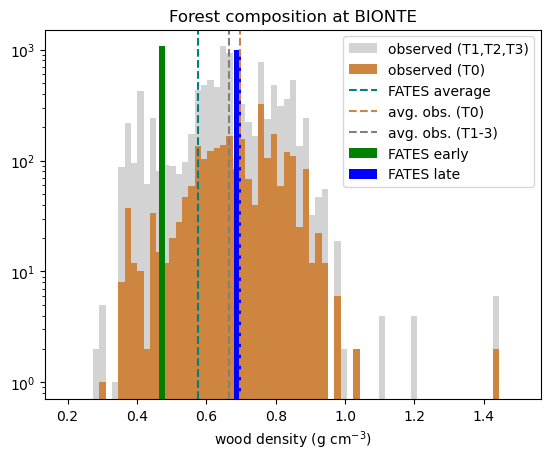

In [27]:
fates_early=nplants_unrolled.isel(fates_levscls=slice(2,13)).sum(dim='fates_levscls').mean(dim="time").isel(fates_levpft=0).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')*total_area
fates_late=nplants_unrolled.isel(fates_levscls=slice(2,13)).sum(dim='fates_levscls').mean(dim="time").isel(fates_levpft=1).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')*total_area
wd_early=0.472 #g/cm3
wd_late=0.6903

#plt.hist(bionte_wd, range=(0.2,1.5), bins=71,color="lightgrey",label="observed (all plots)")
plt.hist(np.concatenate((bionte_wd[all_t1_ind],bionte_wd[all_t2_ind],bionte_wd[all_t3_ind])), range=(0.2,1.5), bins=71,color="lightgrey",label="observed (T1,T2,T3)")
plt.hist(bionte_wd[all_t0_ind], range=(0.2,1.5), bins=71,color="peru",label="observed (T0)")

# Add individual bars for FATES data
bar_width = (1.5-0.2)/71  # Match the histogram bin width
plt.bar(wd_early, fates_early, width=bar_width, color='green', label='FATES early')
plt.bar(wd_late, fates_late, width=bar_width, color='blue', label='FATES late')

# Add vertical lines showing mean WD in each BIONTE plot:
plt.axvline((fates_early*wd_early + fates_late*wd_late)/(fates_early+fates_late),color="teal",linestyle="dashed",label="FATES average")
plt.axvline(np.nanmean(bionte_wd[all_t0_ind]),color="peru",label="avg. obs. (T0)",linestyle="dashed")
#plt.axvline(np.nanmean(bionte_wd[all_t1_ind]),color="lightgrey",label="average observed (T1)",linestyle="dotted")
#plt.axvline(np.nanmean(bionte_wd[all_t2_ind]),color="grey",label="average observed (T2)",linestyle="dashdot")
#plt.axvline(np.nanmean(bionte_wd[all_t3_ind]),color="black",label="average observed (T3)",linestyle="dashed")
plt.axvline(np.nanmean(np.concatenate((bionte_wd[all_t1_ind],bionte_wd[all_t2_ind],bionte_wd[all_t3_ind]))), linestyle="dashed",color="grey",label="avg. obs. (T1-3)")

plt.yscale('log')  # Set logarithmic y-scale
plt.xlabel('wood density (g cm$^{-3}$)')
plt.title('Forest composition at BIONTE')
plt.legend()

In [40]:
np.nanmean(bionte_wd),np.nanmedian(bionte_wd),np.nanstd(bionte_wd)

(0.6726759473918714, 0.6660013824884793, 0.13584355740330734)

In [41]:
np.nanmean(bionte_wd[all_t0_ind]),np.nanmedian(bionte_wd[all_t0_ind]),np.nanstd(bionte_wd[all_t0_ind])

(0.6973351386751043, 0.6982115384615385, 0.12093585815259059)

In [42]:
np.nanmean(bionte_wd[all_t1_ind]),np.nanmedian(bionte_wd[all_t1_ind]),np.nanstd(bionte_wd[all_t1_ind])

(0.6685783391459256, 0.6655315493327663, 0.14038361391770546)

In [43]:
np.nanmean(bionte_wd[all_t2_ind]),np.nanmedian(bionte_wd[all_t2_ind]),np.nanstd(bionte_wd[all_t2_ind])

(0.66553553197058, 0.6619577281191806, 0.1354213820649994)

In [44]:
np.nanmean(bionte_wd[all_t3_ind]),np.nanmedian(bionte_wd[all_t3_ind]),np.nanstd(bionte_wd[all_t3_ind])

(0.665034075348396, 0.6562619047619048, 0.13991323286427598)

In [46]:
np.nanmean(np.concatenate((bionte_wd[all_t1_ind],bionte_wd[all_t2_ind],bionte_wd[all_t3_ind]))),np.nanmedian(np.concatenate((bionte_wd[all_t1_ind],bionte_wd[all_t2_ind],bionte_wd[all_t3_ind]))),np.nanstd(np.concatenate((bionte_wd[all_t1_ind],bionte_wd[all_t2_ind],bionte_wd[all_t3_ind])))

(0.6663854410264165, 0.6619577281191806, 0.1386913655019877)

In [49]:
(fates_early*wd_early + fates_late*wd_late)/(fates_early+fates_late)

<xarray.DataArray 'FATES_NPLANT_SZPF' ()>
array(0.54588725)

In [31]:
## Compare unlogged plot (TO) to logged plots (T1, T2, T3)
all_logged=np.concatenate((bionte_wd[all_t1_ind],bionte_wd[all_t2_ind],bionte_wd[all_t3_ind]))

#Remove NaNs from both arrays
bionte_wd_clean = all_logged[~np.isnan(all_logged)]
bionte_wd_t0_clean = bionte_wd[all_t0_ind][~np.isnan(bionte_wd[all_t0_ind])]

# Now run K-S test on clean data
ks_statistic, p_value = stats.ks_2samp(bionte_wd_clean, bionte_wd_t0_clean)
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.20f}")
if p_value < 0.05:
    print("Distributions are significantly different (p < 0.05)")
else:
    print("No significant difference between distributions")

# And calculate means/medians
print(f"Logged plots - Mean: {bionte_wd_clean.mean():.3f}, Median: {np.median(bionte_wd_clean):.3f}")
print(f"T0 only - Mean: {bionte_wd_t0_clean.mean():.3f}, Median: {np.median(bionte_wd_t0_clean):.3f}")
percent_change = ((bionte_wd_t0_clean.mean() - bionte_wd_clean.mean()) / bionte_wd_clean.mean()) * 100
print(f"Percent change in mean: {percent_change:.1f}%")
percent_change = ((np.median(bionte_wd_t0_clean) - np.median(bionte_wd_clean)) / np.median(bionte_wd_clean)) * 100
print(f"Percent change in median: {percent_change:.1f}%")

K-S statistic: 0.1504
p-value: 0.00000000000000000000
Distributions are significantly different (p < 0.05)
Logged plots - Mean: 0.666, Median: 0.662
T0 only - Mean: 0.697, Median: 0.698
Percent change in mean: 4.6%
Percent change in median: 5.5%


In [46]:
# dataset has DBH by year for 1980 - 2023
nyears=44

years= np.arange(1980,2024,1)
dbh_by_year= np.zeros((nyears,ntrees))

for i in range(nyears):
    dbh_by_year[i,:]=df[str(years[i])].values

In [15]:
dbh_by_year.shape

(44, 15355)

In [47]:
# fates_levscls = [  0.,   5.,  10.,  15.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]

size_class_bot=[0.,5.,10.,15., 20., 30., 40., 50., 60., 70., 80., 90.,100.]
bin_widths=[5,5,5,5,10,10,10,10,10,10,10,10]


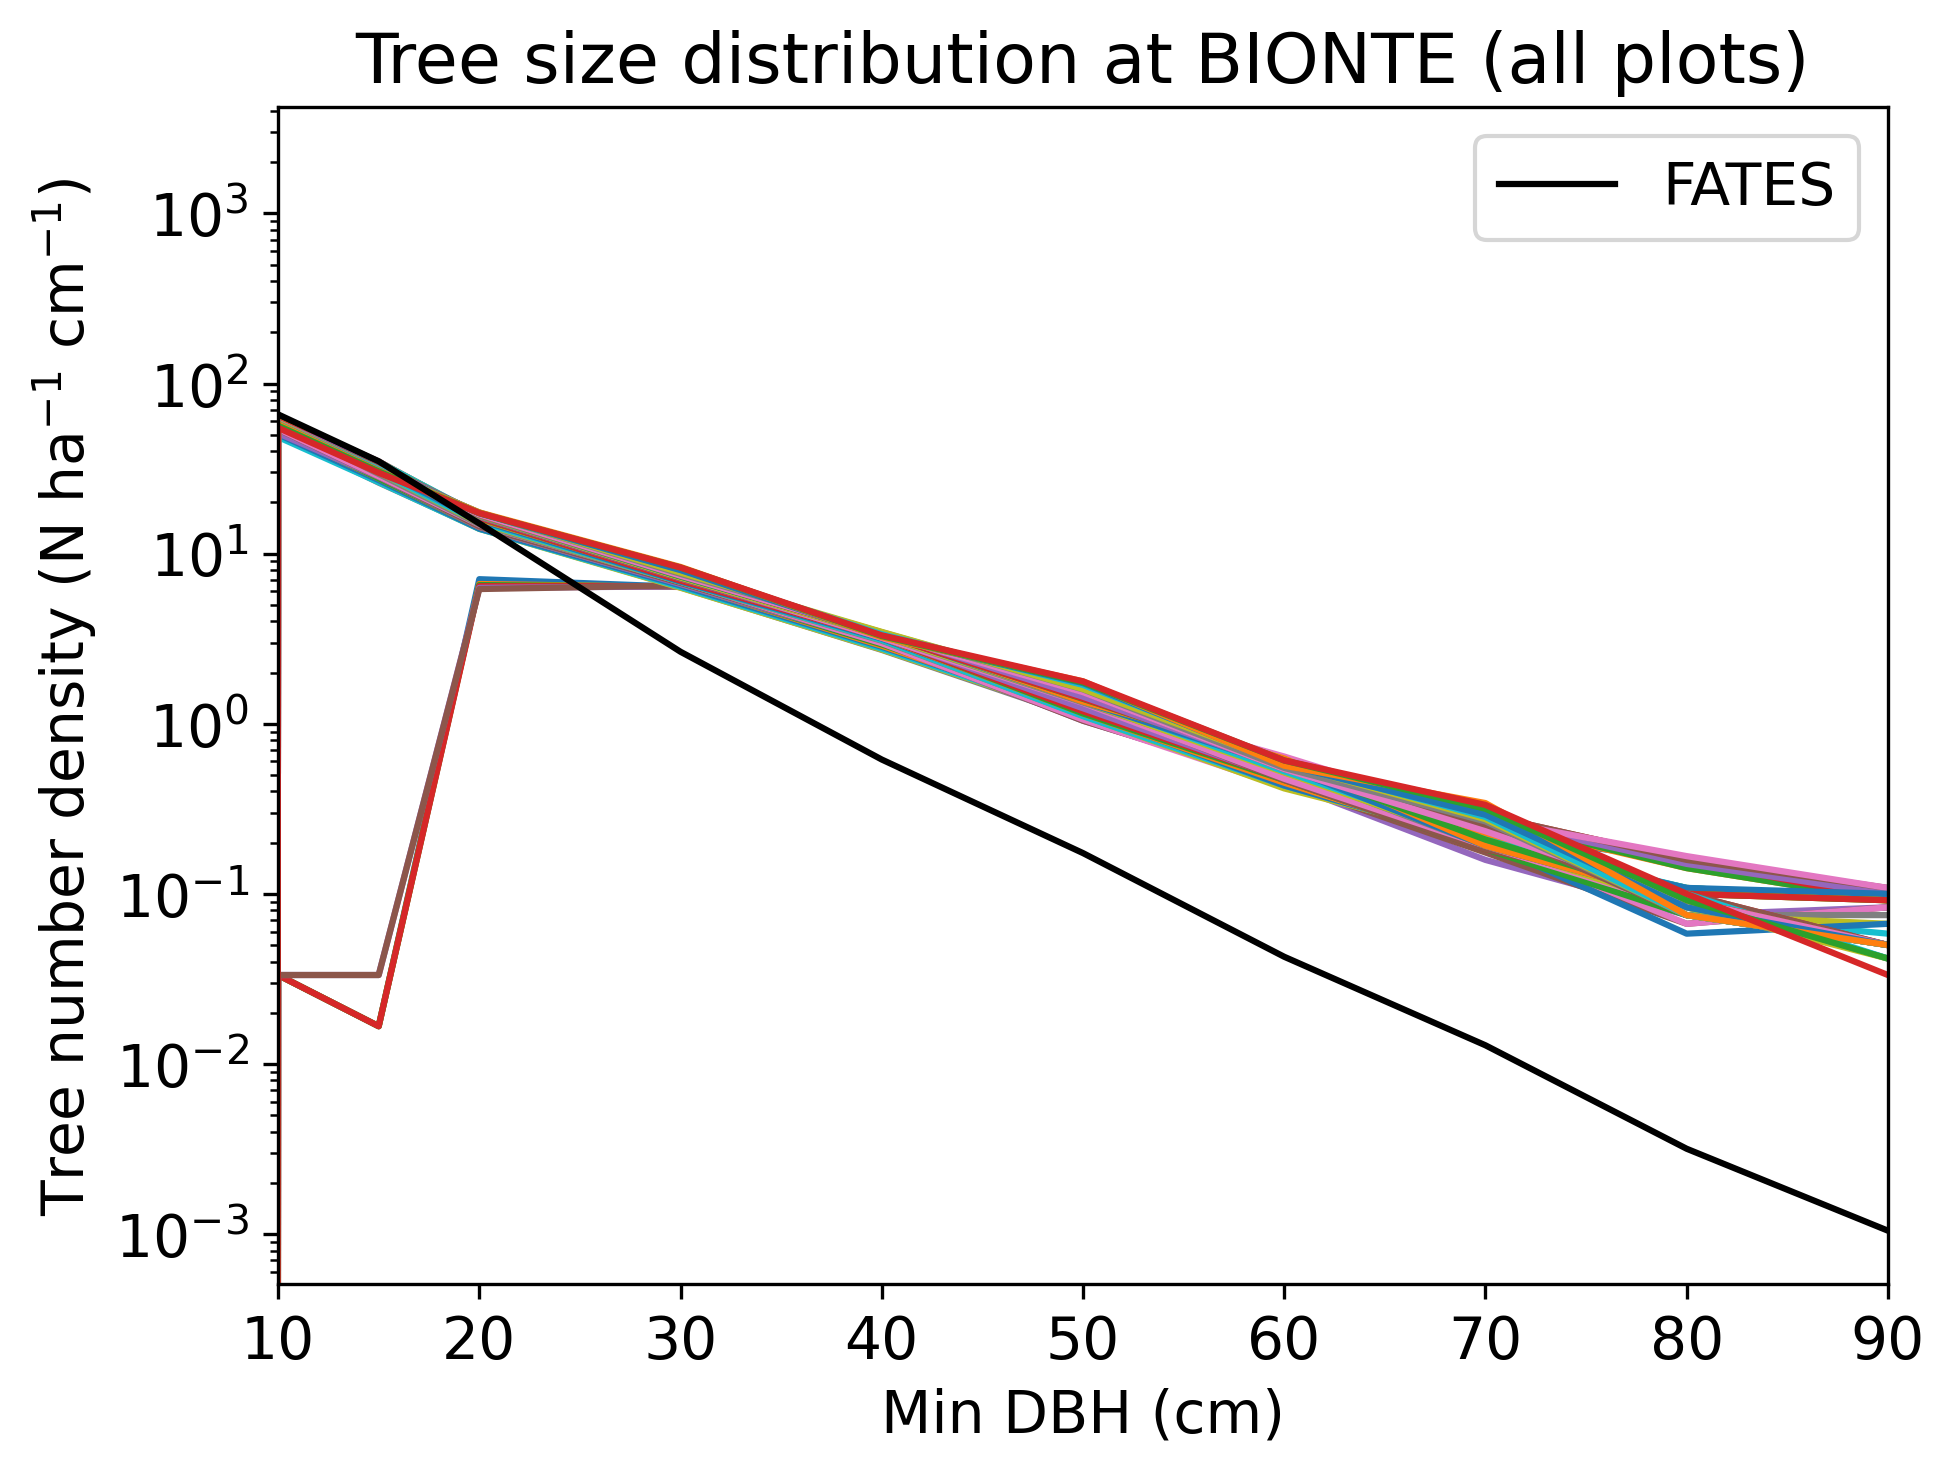

In [65]:
census_size_struc=np.zeros((nyears,len(size_class_bot)-1))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    plt.plot(size_class_bot[0:12],10000.*census_size_struc[i,:]/(4*total_area)/bin_widths)

((10000.*nplants_unrolled.isel(fates_levscls=slice(0,12)).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon'))/bin_widths).plot(x='fates_levscls',color="black",linestyle="solid",label="FATES")#, before parameter adjustment")

#plt.plot(size_class_bot[0:12],92 * np.exp(-0.087 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.087x}$")
#plt.plot(size_class_bot[5:12],9527 * np.exp(-0.23 * np.array(size_class_bot[5:12])),color="grey",linestyle="dotted",linewidth=2,label="y = 9527 e$^{-0.23x}$")
#plt.plot(size_class_bot[0:12],92 * np.exp(-0.053 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.053x}$")

plt.xlabel("Min DBH (cm)")
plt.ylabel("Tree number density (N ha$^{-1}$ cm$^{-1}$)")

plt.title("Tree size distribution at BIONTE (all plots)")# (all trees)")
plt.yscale('log')
plt.xlim(10,90)
plt.legend()

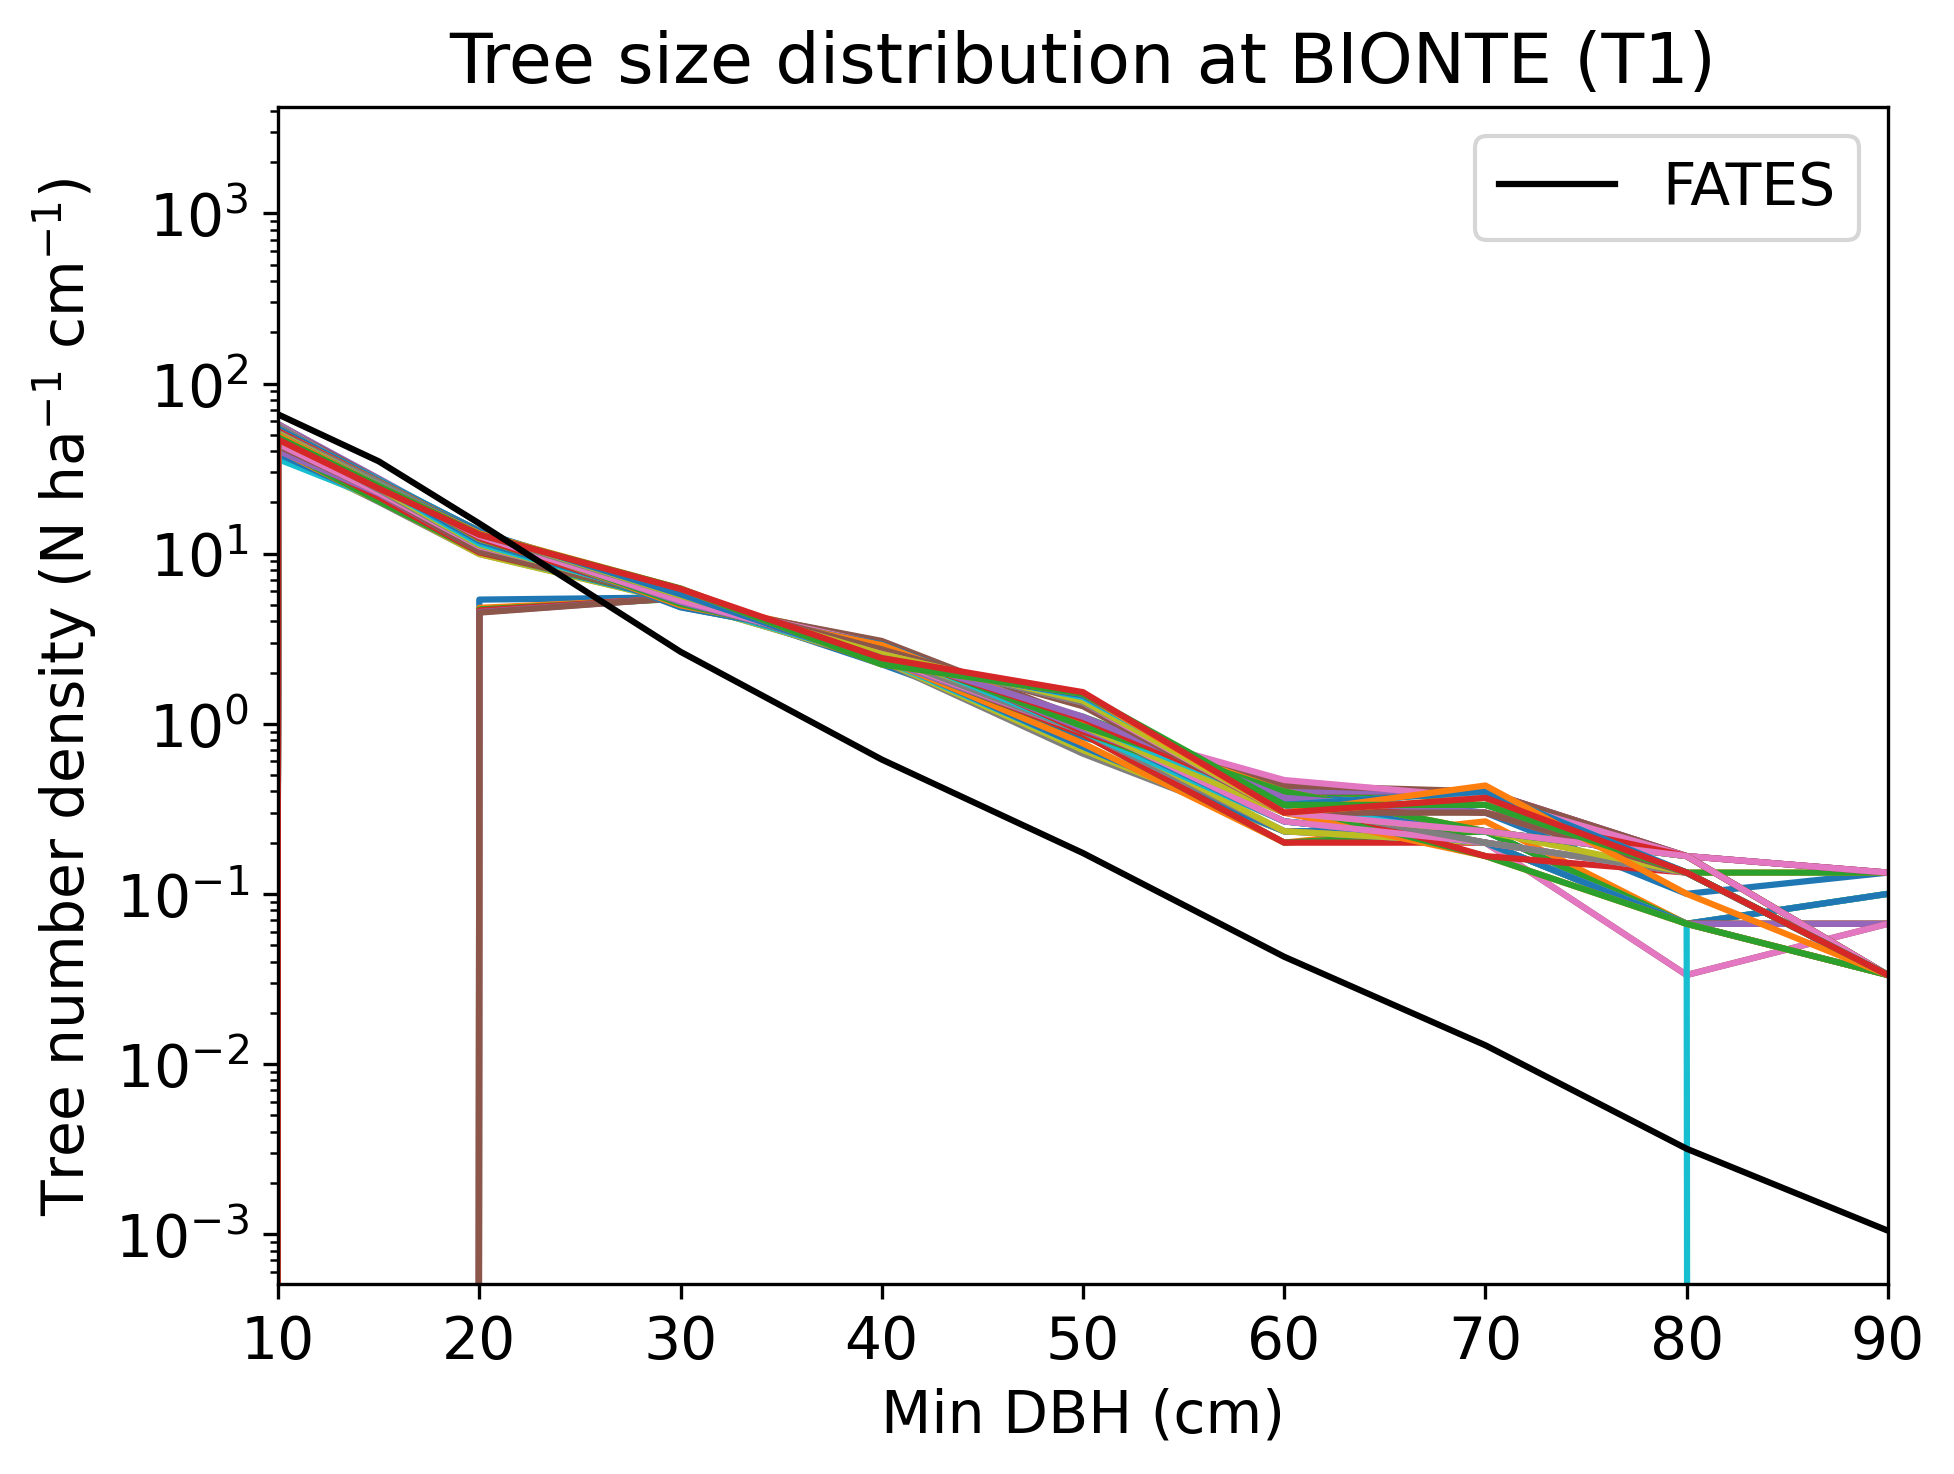

In [64]:
census_size_struc=np.zeros((nyears,len(size_class_bot)-1))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((treatment == 'T1') & (df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    plt.plot(size_class_bot[0:12],10000.*census_size_struc[i,:]/total_area/bin_widths)

((10000.*nplants_unrolled.isel(fates_levscls=slice(0,12)).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon'))/bin_widths).plot(x='fates_levscls',color="black",linestyle="solid",label="FATES")#, before parameter adjustment")

#plt.plot(size_class_bot[0:12],92 * np.exp(-0.087 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.087x}$")
#plt.plot(size_class_bot[5:12],9527 * np.exp(-0.23 * np.array(size_class_bot[5:12])),color="grey",linestyle="dotted",linewidth=2,label="y = 9527 e$^{-0.23x}$")
#plt.plot(size_class_bot[0:12],92 * np.exp(-0.053 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.053x}$")

plt.xlabel("Min DBH (cm)")
plt.ylabel("Tree number density (N ha$^{-1}$ cm$^{-1}$)")

plt.title("Tree size distribution at BIONTE (T1)")# (all trees)")
plt.yscale('log')
plt.xlim(10,90)
plt.legend()

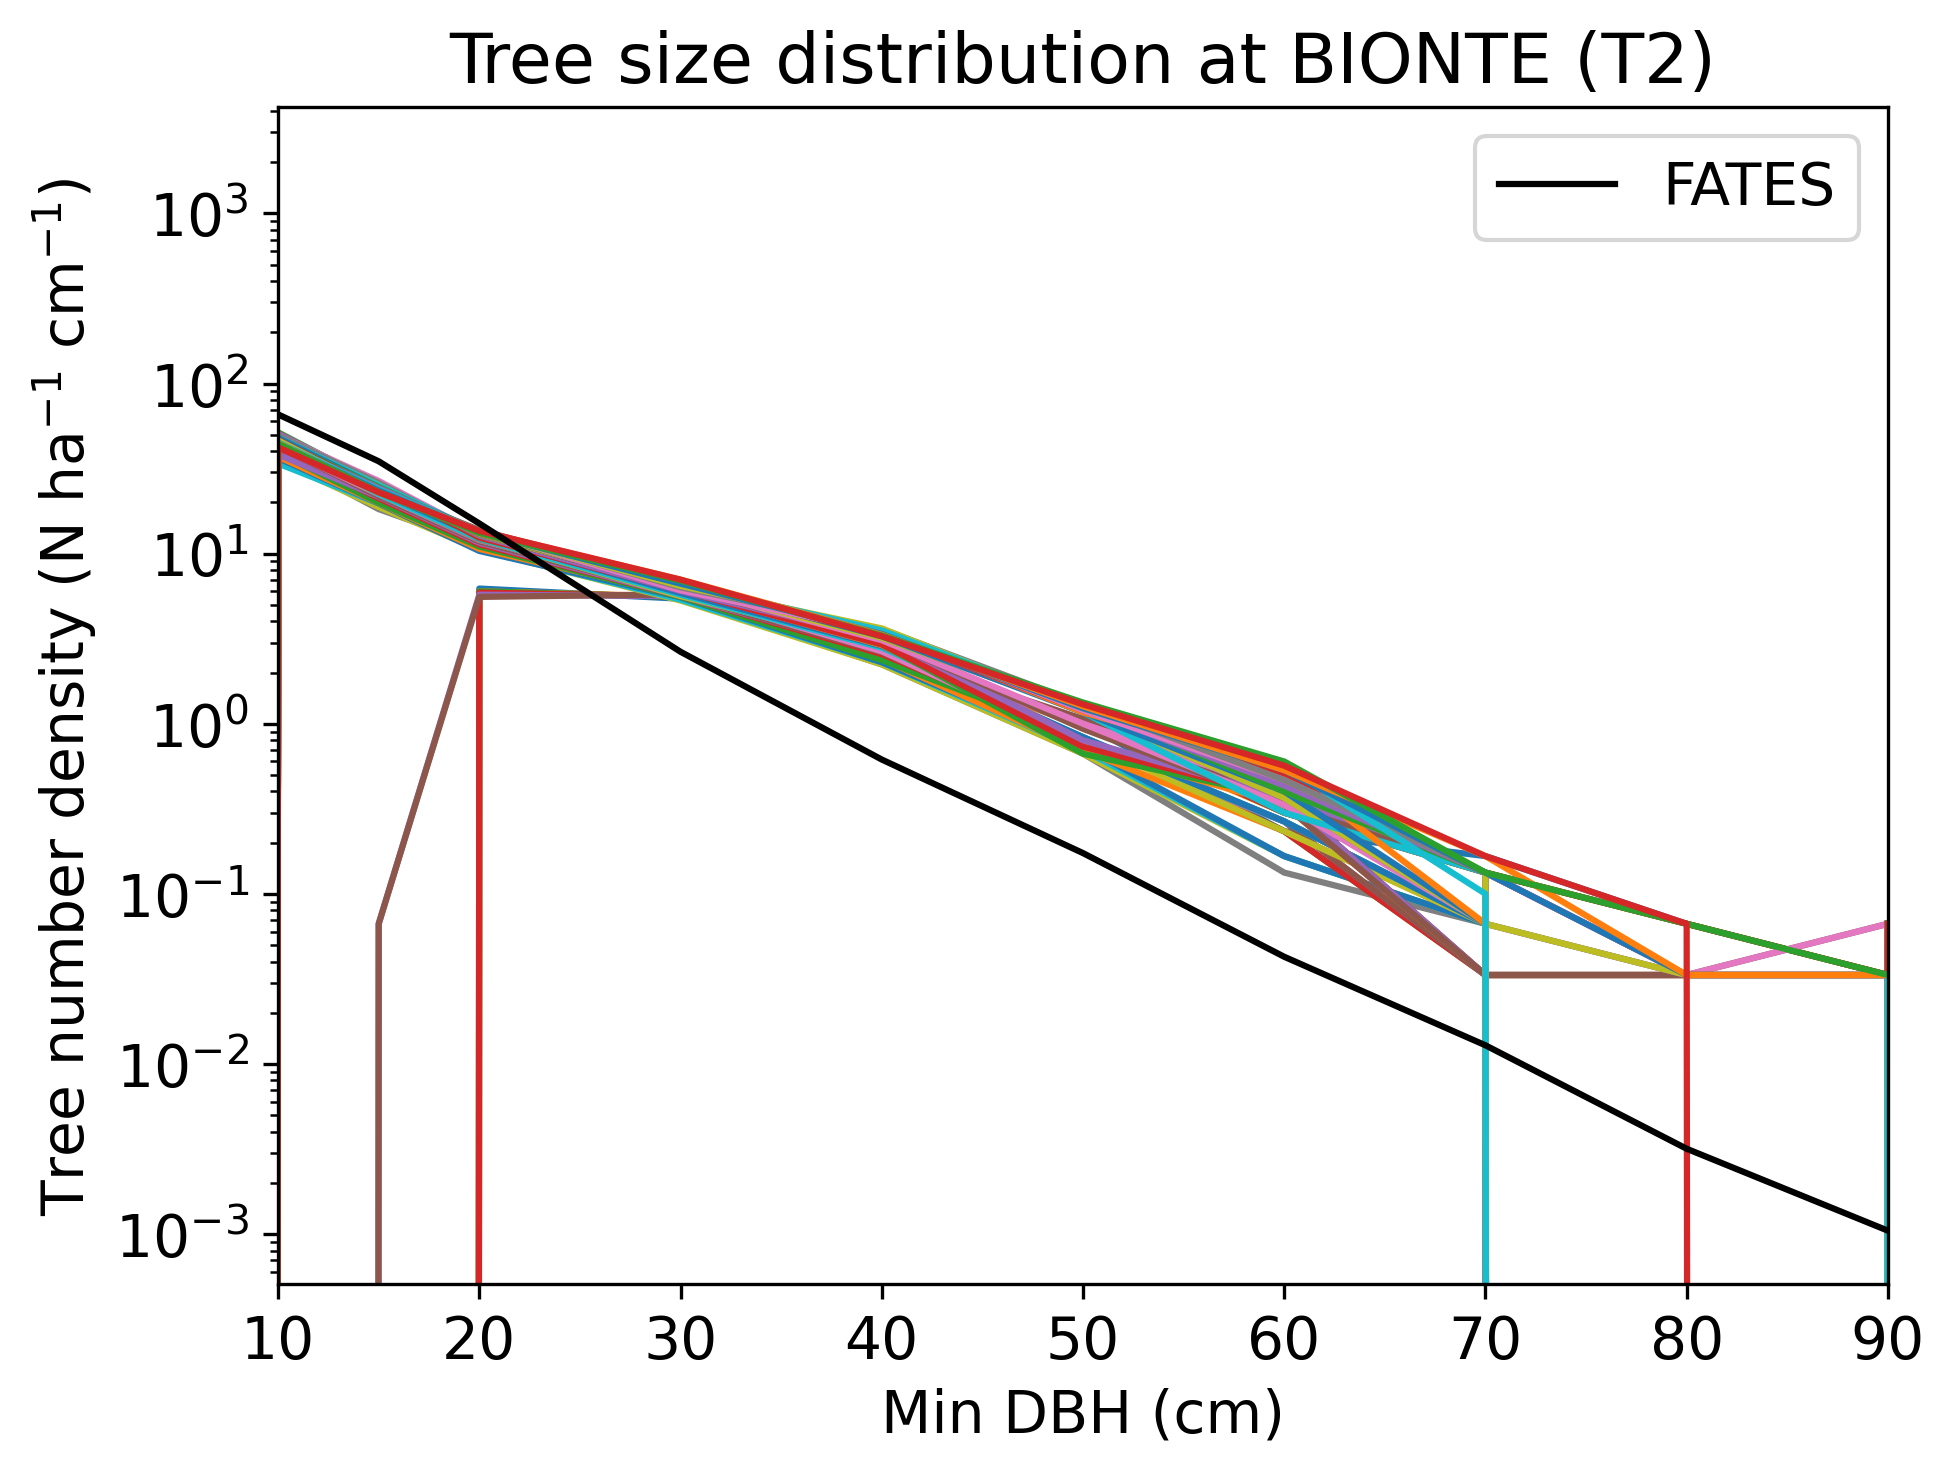

In [63]:
census_size_struc=np.zeros((nyears,len(size_class_bot)-1))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((treatment == 'T2') & (df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    plt.plot(size_class_bot[0:12],10000.*census_size_struc[i,:]/total_area/bin_widths)

((10000.*nplants_unrolled.isel(fates_levscls=slice(0,12)).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon'))/bin_widths).plot(x='fates_levscls',color="black",linestyle="solid",label="FATES")#, before parameter adjustment")

#plt.plot(size_class_bot[0:12],92 * np.exp(-0.087 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.087x}$")
#plt.plot(size_class_bot[5:12],9527 * np.exp(-0.23 * np.array(size_class_bot[5:12])),color="grey",linestyle="dotted",linewidth=2,label="y = 9527 e$^{-0.23x}$")
#plt.plot(size_class_bot[0:12],92 * np.exp(-0.053 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.053x}$")

plt.xlabel("Min DBH (cm)")
plt.ylabel("Tree number density (N ha$^{-1}$ cm$^{-1}$)")

plt.title("Tree size distribution at BIONTE (T2)")# (all trees)")
plt.yscale('log')
plt.xlim(10,90)
plt.legend()

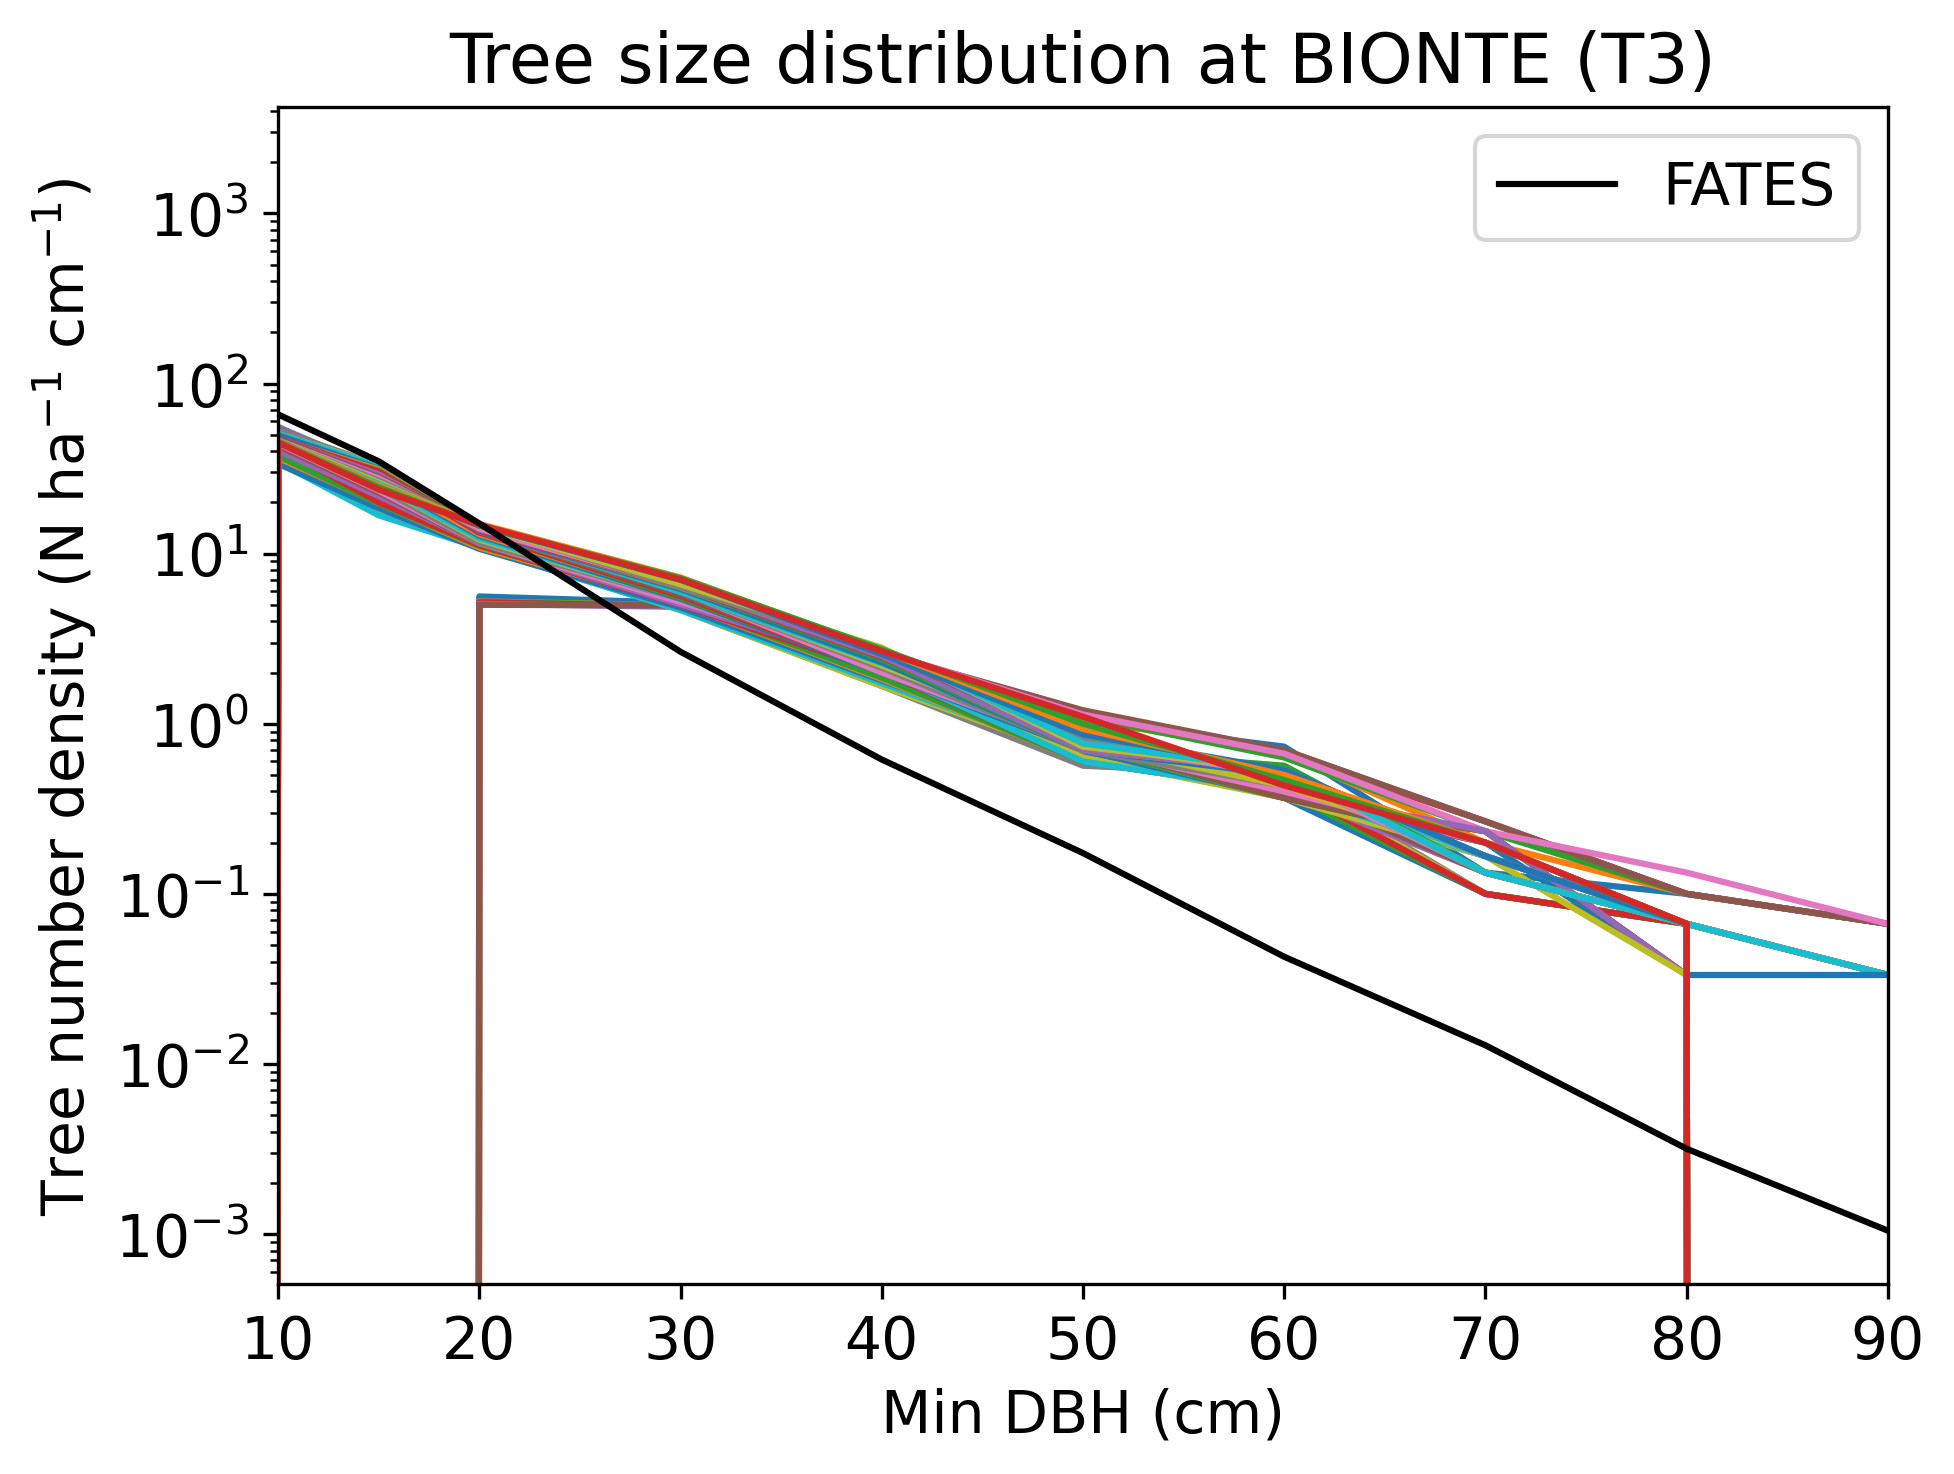

In [62]:
census_size_struc=np.zeros((nyears,len(size_class_bot)-1))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((treatment == 'T3') & (df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    plt.plot(size_class_bot[0:12],10000.*census_size_struc[i,:]/total_area/bin_widths)

((10000.*nplants_unrolled.isel(fates_levscls=slice(0,12)).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon'))/bin_widths).plot(x='fates_levscls',color="black",linestyle="solid",label="FATES")#, before parameter adjustment")

#plt.plot(size_class_bot[0:12],92 * np.exp(-0.087 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.087x}$")
#plt.plot(size_class_bot[5:12],9527 * np.exp(-0.23 * np.array(size_class_bot[5:12])),color="grey",linestyle="dotted",linewidth=2,label="y = 9527 e$^{-0.23x}$")
#plt.plot(size_class_bot[0:12],92 * np.exp(-0.076 * np.array(size_class_bot[0:12])),color="darkgrey",linestyle="dashdot",linewidth=2,label="y = 92 e$^{-0.076x}$")

plt.xlabel("Min DBH (cm)")
plt.ylabel("Tree number density (N ha$^{-1}$ cm$^{-1}$)")

plt.title("Tree size distribution at BIONTE (T3)")# (all trees)")
plt.yscale('log')
plt.xlim(10,90)
plt.legend()

In [73]:
d0.fates_levscls

<xarray.DataArray 'fates_levscls' (fates_levscls: 13)>
array([  0.,   5.,  10.,  15.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90.,
       100.], dtype=float32)
Coordinates:
  * fates_levscls  (fates_levscls) float32 0.0 5.0 10.0 15.0 ... 80.0 90.0 100.0
Attributes:
    long_name:  FATES diameter size class lower bound
    units:      cm

In [74]:
# FATES
x=d0.fates_levscls.isel(fates_levscls=slice(2,12)).data
y=((10000.*nplants_unrolled.isel(fates_levscls=slice(2,12)).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon')).data/bin_widths[2:])
# 1. Fit the linear model to (x, log(y))
# slope = B, intercept = ln(A)
slope, intercept = np.polyfit(x, np.log(y), 1)

# 2. Recover the original constant A
A = np.exp(intercept)
B = slope

print(f"Equation: y = {A:.2f} * e^({B:.2f} * x)")

Equation: y = 221.25 * e^(-0.14 * x)


In [55]:
# observed -- all treatments
census_size_struc=np.zeros((nyears,len(size_class_bot)-1))
obs_slopes=np.zeros((nyears))
obs_ints=np.zeros((nyears))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    x=size_class_bot[2:12]
    y=10000.*census_size_struc[i,2:12]/(4*total_area)/bin_widths[2:12]
    slope, intercept = np.polyfit(x, np.log(y), 1)
    A = np.exp(intercept)
    B = slope
#    print(f"Equation: y = {A:.2f} * e^({B:.2f} * x)")
    obs_slopes[i]=B
    obs_ints[i]=A

In [56]:
np.nanmean(obs_slopes),np.nanstd(obs_slopes)

(-0.07596214771900855, 0.02787712563442493)

In [57]:
np.nanmean(obs_ints),np.nanstd(obs_ints)

(92.6206146146635, 39.29149215103079)

In [76]:
size_class_bot

[0.0, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0]

In [116]:
# observed -- unlogged
census_size_struc=np.zeros((nyears,len(size_class_bot)-1))
obs_slopes=np.zeros((nyears))
obs_ints=np.zeros((nyears))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((treatment == 'T0') & (df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    x=size_class_bot[6:12]
    y=10000.*census_size_struc[i,6:12]/total_area/bin_widths[6:12]
    slope, intercept = np.polyfit(x, np.log(y), 1)
    A = np.exp(intercept)
    B = slope
#    print(f"Equation: y = {A:.2f} * e^({B:.2f} * x)")
    obs_slopes[i]=B
    obs_ints[i]=A

In [120]:
np.nanmedian(obs_slopes),np.nanstd(obs_slopes)

(-0.08737599753253633, 0.005165152975165417)

In [121]:
np.nanmedian(obs_ints),np.nanstd(obs_ints)

(89.35352818506482, 33.7308607363002)

Text(55, 6, 'colored lines: observed')

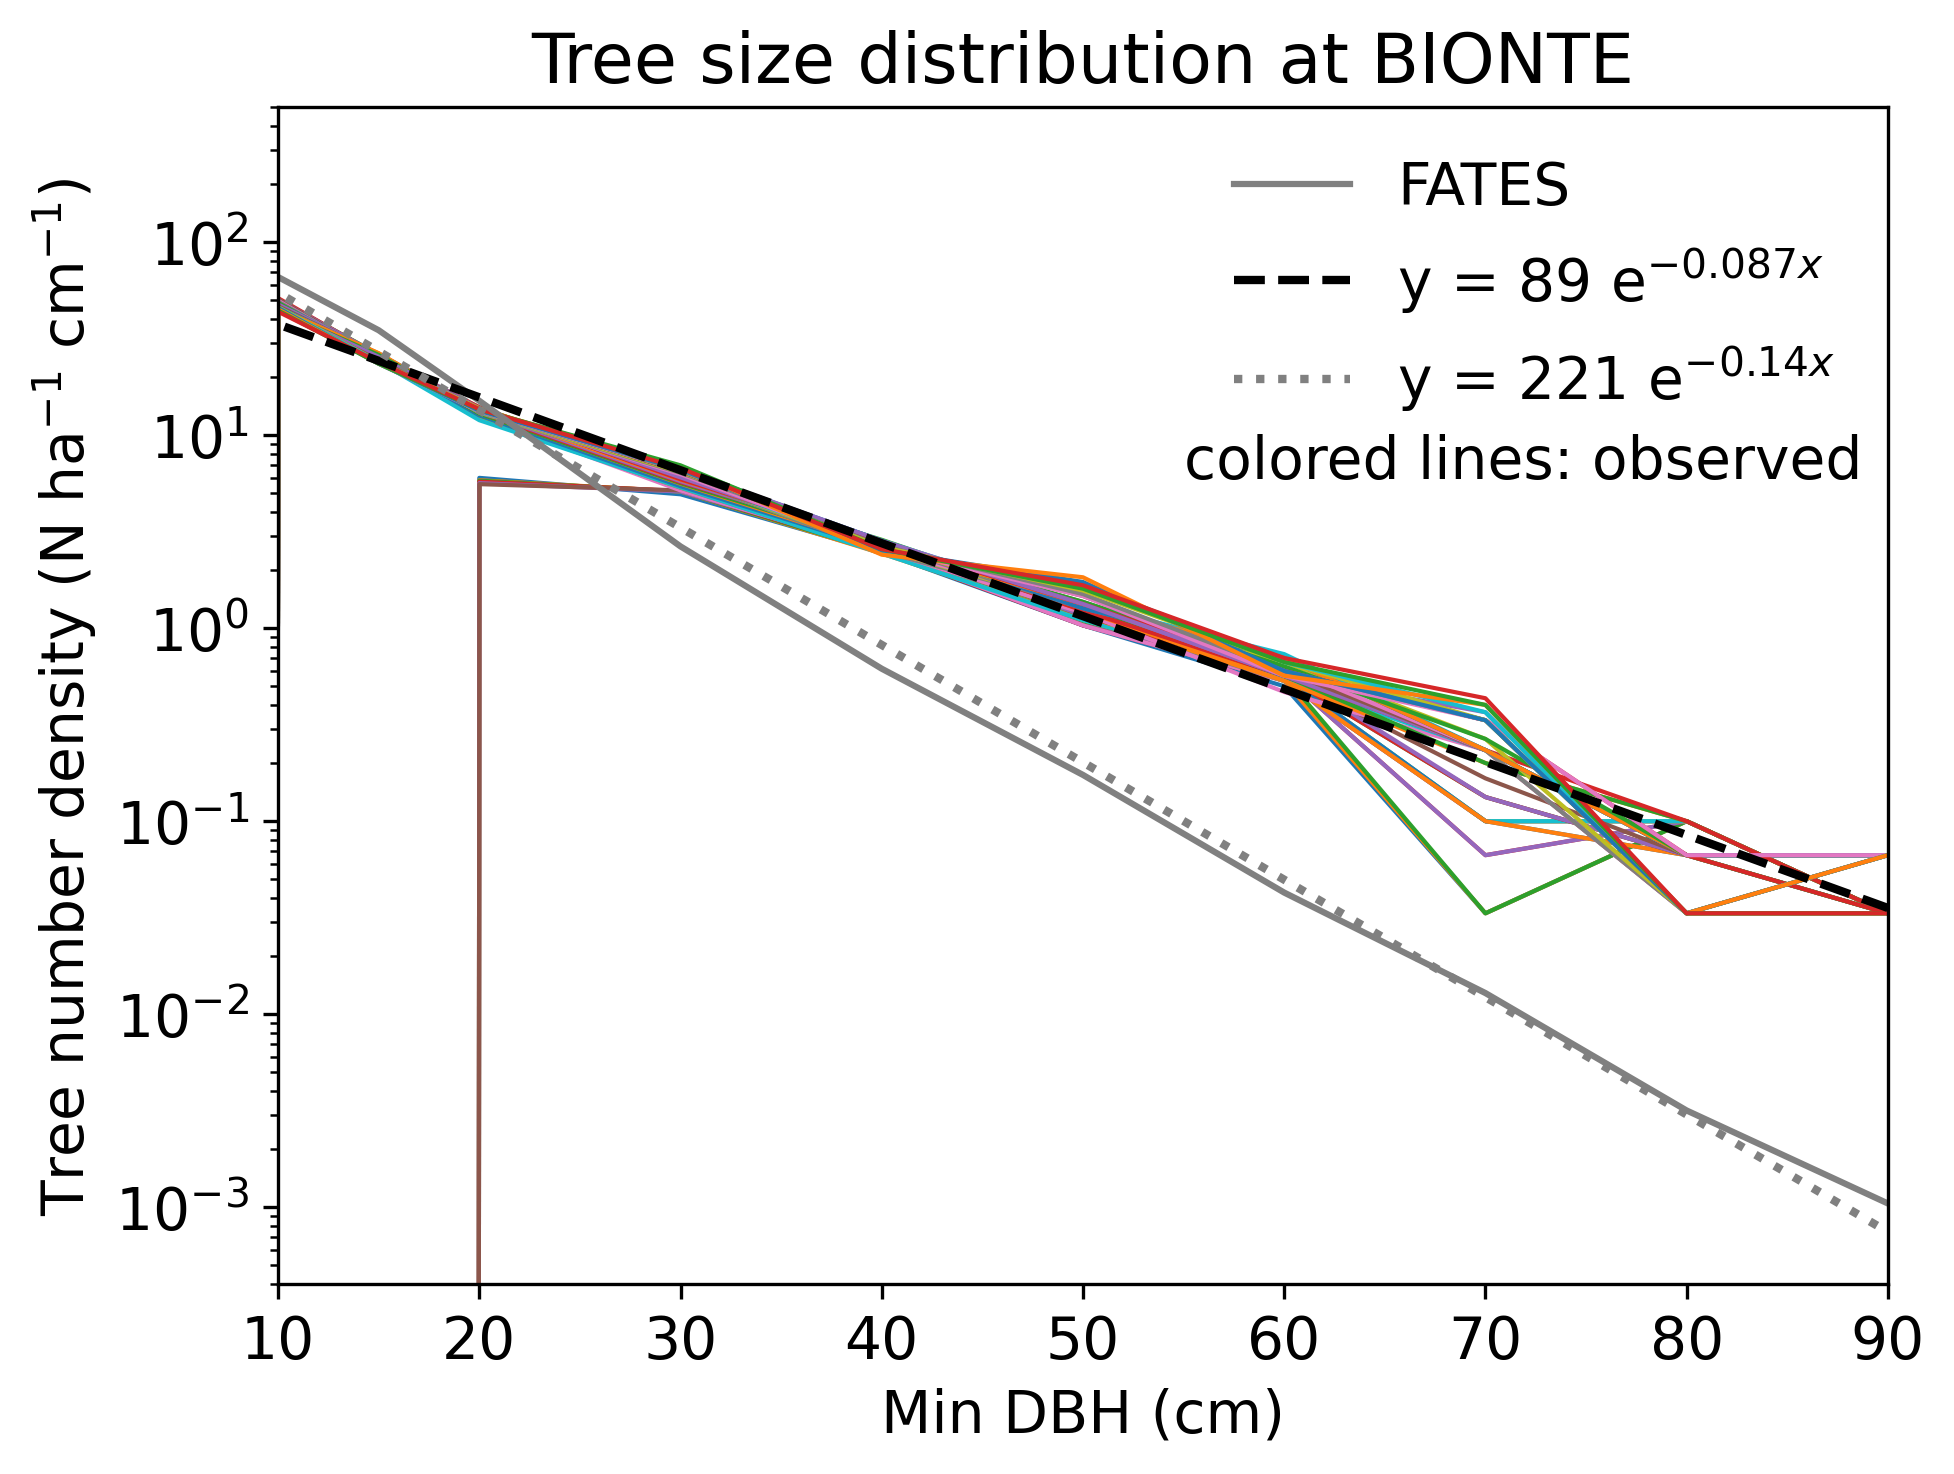

In [122]:
# change units to compare to Figure 7 here: https://bg.copernicus.org/articles/17/3017/2020/bg-17-3017-2020.html#&gid=1&pid=1
# use T0 (unlogged plot)

census_size_struc=np.zeros((nyears,len(size_class_bot)-1))

for i in range(nyears):
    for j in range(len(size_class_bot)-1):
        blah1=np.where((treatment == 'T0') & (df[str(years[i])].values > size_class_bot[j]) & (df[str(years[i])].values < size_class_bot[j+1]))
        census_size_struc[i,j]=len(blah1[0])
    plt.plot(size_class_bot[0:12],10000.*census_size_struc[i,:]/total_area/bin_widths,linewidth=1)

((10000.*nplants_unrolled.isel(fates_levscls=slice(0,12)).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon'))/bin_widths).plot(x='fates_levscls',color="grey",linestyle="solid",label="FATES")#, before parameter adjustment")

plt.plot(size_class_bot[0:12],89.35 * np.exp(-0.087 * np.array(size_class_bot[0:12])),color="black",linestyle="dashed",linewidth=2,label="y = 89 e$^{-0.087x}$")

plt.plot(size_class_bot[0:12],221.25 * np.exp(-0.14 * np.array(size_class_bot[0:12])),color="grey",linestyle="dotted",linewidth=2,label="y = 221 e$^{-0.14x}$")

plt.xlabel("Min DBH (cm)")
plt.ylabel("Tree number density (N ha$^{-1}$ cm$^{-1}$)")

plt.title("Tree size distribution at BIONTE")# (all trees)")
plt.yscale('log')
plt.xlim(10,90)
plt.ylim(4*10**(-4),500)
plt.legend(frameon=False)
plt.text(55,6,'colored lines: observed')